# 鲜做和老化对比按照组别的示意图


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Font
import matplotlib.font_manager as fm

# ==========================================
# 1. 字体兼容性处理（解决中文显示问题）
# ==========================================
def set_chinese_font():
    font_names = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'Heiti TC', 'STHeiti']
    for font in font_names:
        if font in [f.name for f in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [font]
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

used_font = set_chinese_font()
print(f"当前使用的字体: {used_font if used_font else '系统默认'}")

# ==========================================
# 2. 读取并整理鲜做/老化面包数据（修正逻辑错误）
# ==========================================
def load_tpa_data(fresh_file, aged_file):
    # 定义所有组别（与工作表名称一致）
    all_groups = ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3']
    # 定义TPA指标（与数据中一致）
    indicators = ['硬度', '内聚性', '弹性', '胶粘性', '咀嚼性']
    # 按A/B/C组分类
    group_categories = {
        'A组': ['A1', 'A2', 'A3'],
        'B组': ['B1', 'B2', 'B3'],
        'C组': ['C1', 'C2', 'C3']
    }
    
    # 存储数据：{组类别: {组别: {指标: {鲜做: [], 老化: []}}}}
    tpa_data = {cat: {} for cat in group_categories.keys()}
    
    # 读取鲜做面包数据（每个工作表对应一个组别）
    fresh_sheets = {sheet: pd.read_excel(fresh_file, sheet_name=sheet) for sheet in all_groups}
    # 读取老化面包数据（每个工作表对应一个组别）
    aged_sheets = {sheet: pd.read_excel(aged_file, sheet_name=sheet) for sheet in all_groups}
    
    # 整理数据（修正：先遍历组别，再给tpa_data[cat][group]赋值）
    for cat, groups in group_categories.items():
        for group in groups:
            tpa_data[cat][group] = {}  # 每个组别单独初始化
            # 提取鲜做组数据
            fresh_df = fresh_sheets[group]
            # 提取老化组数据
            aged_df = aged_sheets[group]
            
            for indicator in indicators:
                # 提取指标对应的数值（去除空值）
                fresh_vals = fresh_df[fresh_df.iloc[:, 0] == indicator].iloc[0, 1:].dropna().values.astype(float)
                aged_vals = aged_df[aged_df.iloc[:, 0] == indicator].iloc[0, 1:].dropna().values.astype(float)
                tpa_data[cat][group][indicator] = {'fresh': fresh_vals, 'aged': aged_vals}
    
    return tpa_data, indicators, group_categories

# ==========================================
# 3. 计算均值与标准差（用于图表展示）
# ==========================================
def calc_stats(data_list):
    """计算数据的均值和标准差"""
    return np.mean(data_list), np.std(data_list)

# ==========================================
# 4. 绘制单组均值对比柱状图（鲜做/老化分开）
# ==========================================
def draw_single_group_plot(cat_name, indicator, group_data, group_type, save_path):
    """
    cat_name: 组类别（如A组）
    indicator: TPA指标（如硬度）
    group_data: 该组别的数据（{组别: {fresh/aged: []}}）
    group_type: 组类型（鲜做/老化）
    save_path: 图表保存路径
    """
    groups = list(group_data.keys())  # 如[A1, A2, A3]
    x = np.arange(len(groups))
    width = 0.5  # 单组柱子宽度
    
    # 计算每个组别的均值与标准差
    means, stds = [], []
    for group in groups:
        val_mean, val_std = calc_stats(group_data[group][group_type])
        means.append(round(val_mean, 2))
        stds.append(round(val_std, 2))
    
    # 选择颜色（鲜做=蓝色，老化=橙色）
    color = '#5B9BD5' if group_type == 'fresh' else '#ED7D31'
    title_suffix = '鲜做面包' if group_type == 'fresh' else '老化面包'
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
    
    # 绘制单组柱子
    bars = ax.bar(x, means, width, yerr=stds,
                  color=color, edgecolor='black',
                  capsize=6, error_kw={'elinewidth': 1.5})
    
    # 添加数值标注（右侧标注，避免遮挡误差线）
    def add_value_labels(bars, means, color):
        for bar, mean in zip(bars, means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width(), height,
                    f'{mean:.2f}', ha='left', va='center',
                    fontsize=10, fontweight='bold', color=color)
    
    add_value_labels(bars, means, color)
    
    # 图表样式美化
    ax.set_title(f'{cat_name} {indicator}对比（{title_suffix}）', fontsize=14, pad=20, fontweight='bold')
    ax.set_xlabel('组别', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{indicator}值', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    
    # 移除上、右边框，添加Y轴网格线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    
    # 调整X轴范围，预留标注空间
    ax.set_xlim(-0.5, len(groups) - 0.5 + 0.4)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"图表已保存：{save_path}")

# ==========================================
# 5. 批量生成所有图表（鲜做/老化分开）
# ==========================================
def generate_all_plots(tpa_data, indicators, group_categories, plot_dir):
    # 创建图表保存目录
    os.makedirs(plot_dir, exist_ok=True)
    # 记录图表路径（用于后续嵌入Excel）
    plot_paths = {
        '鲜做组': {cat: {} for cat in group_categories.keys()},
        '老化组': {cat: {} for cat in group_categories.keys()}
    }
    
    for cat, groups in group_categories.items():
        # 提取该组别的数据
        cat_data = {g: tpa_data[cat][g] for g in groups}
        
        # 生成鲜做组图表
        for indicator in indicators:
            indicator_data = {g: cat_data[g][indicator] for g in groups}
            plot_filename = f'鲜做_{cat}_{indicator}.png'
            plot_save_path = os.path.join(plot_dir, plot_filename)
            draw_single_group_plot(cat, indicator, indicator_data, 'fresh', plot_save_path)
            plot_paths['鲜做组'][cat][indicator] = plot_save_path
        
        # 生成老化组图表
        for indicator in indicators:
            indicator_data = {g: cat_data[g][indicator] for g in groups}
            plot_filename = f'老化_{cat}_{indicator}.png'
            plot_save_path = os.path.join(plot_dir, plot_filename)
            draw_single_group_plot(cat, indicator, indicator_data, 'aged', plot_save_path)
            plot_paths['老化组'][cat][indicator] = plot_save_path
    
    return plot_paths

# ==========================================
# 6. 整理数据并写入Excel（含数据表格+图表嵌入）
# ==========================================
def build_excel(tpa_data, indicators, group_categories, plot_paths, excel_filename):
    # 6.1 构建数据总表（鲜做/老化分开）
    excel_data = []
    for cat, groups in group_categories.items():
        for group in groups:
            for indicator in indicators:
                # 提取鲜做/老化数据的均值与标准差
                fresh_vals = tpa_data[cat][group][indicator]['fresh']
                aged_vals = tpa_data[cat][group][indicator]['aged']
                f_mean, f_std = calc_stats(fresh_vals)
                a_mean, a_std = calc_stats(aged_vals)
                
                excel_data.append({
                    '组类别': cat,
                    '组别': group,
                    'TPA指标': indicator,
                    '鲜做均值': round(f_mean, 2),
                    '鲜做标准差': round(f_std, 2),
                    '老化均值': round(a_mean, 2),
                    '老化标准差': round(a_std, 2)
                })
    df_total = pd.DataFrame(excel_data)
    
    # 6.2 写入Excel数据表格
    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        # 数据总表
        df_total.to_excel(writer, sheet_name='TPA数据总表', index=False)
        # 鲜做组数据
        df_fresh = df_total[['组类别', '组别', 'TPA指标', '鲜做均值', '鲜做标准差']]
        df_fresh.to_excel(writer, sheet_name='鲜做组数据', index=False)
        # 老化组数据
        df_aged = df_total[['组类别', '组别', 'TPA指标', '老化均值', '老化标准差']]
        df_aged.to_excel(writer, sheet_name='老化组数据', index=False)
    
    # 6.3 加载Excel并嵌入图表
    wb = load_workbook(excel_filename)
    
    # 嵌入鲜做组图表
    ws_fresh = wb.create_sheet('鲜做组图表')
    row = 5
    for cat, indicator_plots in plot_paths['鲜做组'].items():
        for indicator, plot_path in indicator_plots.items():
            img = Image(plot_path)
            img.width = img.width * 0.35
            img.height = img.height * 0.35
            ws_fresh.add_image(img, f'A{row}')
            # 图表标题
            title_cell = ws_fresh.cell(row=row-2, column=1, value=f'{cat} {indicator}（鲜做）')
            title_cell.font = Font(bold=True, size=12)
            row += 35
    
    # 嵌入老化组图表
    ws_aged = wb.create_sheet('老化组图表')
    row = 5
    for cat, indicator_plots in plot_paths['老化组'].items():
        for indicator, plot_path in indicator_plots.items():
            img = Image(plot_path)
            img.width = img.width * 0.35
            img.height = img.height * 0.35
            ws_aged.add_image(img, f'A{row}')
            # 图表标题
            title_cell = ws_aged.cell(row=row-2, column=1, value=f'{cat} {indicator}（老化）')
            title_cell.font = Font(bold=True, size=12)
            row += 35
    
    # 6.4 格式化数据表格（调整列宽）
    for sheet_name in ['TPA数据总表', '鲜做组数据', '老化组数据']:
        ws = wb[sheet_name]
        for column in ws.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 25)
            ws.column_dimensions[column_letter].width = adjusted_width
    
    # 保存Excel文件
    wb.save(excel_filename)
    print(f"Excel文件已生成：{os.path.abspath(excel_filename)}")

# ==========================================
# 7. 主函数（执行完整流程）
# ==========================================
def main(fresh_file_path, aged_file_path):
    # 步骤1：读取数据
    tpa_data, indicators, group_categories = load_tpa_data(fresh_file_path, aged_file_path)
    
    # 步骤2：生成所有对比图表
    plot_dir = './tpa_plots'  # 图表保存目录
    plot_paths = generate_all_plots(tpa_data, indicators, group_categories, plot_dir)
    
    # 步骤3：生成Excel文件
    excel_filename = '面包TPA检测结果汇总（鲜做vs老化_单组）.xlsx'
    build_excel(tpa_data, indicators, group_categories, plot_paths, excel_filename)

# ==========================================
# 执行（需替换为你的文件实际路径）
# ==========================================
if __name__ == "__main__":
    # 替换为你的文件路径
    FRESH_FILE = '/Users/wangguotao/Downloads/ISAR/ZJ/鲜做面包.xlsx'
    AGED_FILE = '/Users/wangguotao/Downloads/ISAR/ZJ/室外7度存放两天.xls'
    main(FRESH_FILE, AGED_FILE)

当前使用的字体: Arial Unicode MS
图表已保存：./tpa_plots/鲜做_A组_硬度.png
图表已保存：./tpa_plots/鲜做_A组_内聚性.png
图表已保存：./tpa_plots/鲜做_A组_弹性.png
图表已保存：./tpa_plots/鲜做_A组_胶粘性.png
图表已保存：./tpa_plots/鲜做_A组_咀嚼性.png
图表已保存：./tpa_plots/老化_A组_硬度.png
图表已保存：./tpa_plots/老化_A组_内聚性.png
图表已保存：./tpa_plots/老化_A组_弹性.png
图表已保存：./tpa_plots/老化_A组_胶粘性.png
图表已保存：./tpa_plots/老化_A组_咀嚼性.png
图表已保存：./tpa_plots/鲜做_B组_硬度.png
图表已保存：./tpa_plots/鲜做_B组_内聚性.png
图表已保存：./tpa_plots/鲜做_B组_弹性.png
图表已保存：./tpa_plots/鲜做_B组_胶粘性.png
图表已保存：./tpa_plots/鲜做_B组_咀嚼性.png
图表已保存：./tpa_plots/老化_B组_硬度.png
图表已保存：./tpa_plots/老化_B组_内聚性.png
图表已保存：./tpa_plots/老化_B组_弹性.png
图表已保存：./tpa_plots/老化_B组_胶粘性.png
图表已保存：./tpa_plots/老化_B组_咀嚼性.png
图表已保存：./tpa_plots/鲜做_C组_硬度.png
图表已保存：./tpa_plots/鲜做_C组_内聚性.png
图表已保存：./tpa_plots/鲜做_C组_弹性.png
图表已保存：./tpa_plots/鲜做_C组_胶粘性.png
图表已保存：./tpa_plots/鲜做_C组_咀嚼性.png
图表已保存：./tpa_plots/老化_C组_硬度.png
图表已保存：./tpa_plots/老化_C组_内聚性.png
图表已保存：./tpa_plots/老化_C组_弹性.png
图表已保存：./tpa_plots/老化_C组_胶粘性.png
图表已保存：./tpa_plots/老化_C组_咀嚼性.png
Excel文件已生成：/Users/wangguot

In [17]:
import pandas as pd
import numpy as np
import os
from openpyxl import load_workbook
from openpyxl.styles import Font, Border, Side, Alignment
from openpyxl.utils.dataframe import dataframe_to_rows

# ==========================================
# 1. 定义数据整理与正交分析函数
# ==========================================
def analyze_orthogonal_experiment(data_df, factors, response_col='综合评分'):
    """
    正交实验数据分析：计算各因素各水平的均值K、极差R
    data_df: 原始数据DataFrame
    factors: 因素列名列表（如['水', '酵母', '桑麻粉', '蜂蜜']）
    response_col: 响应值列名（如综合评分）
    return: 因素水平均值表、极差分析表
    """
    # 计算各因素各水平的均值K
    factor_k_dict = {}
    for factor in factors:
        level_values = sorted(data_df[factor].unique())  # 因素水平（排序）
        k_values = [data_df[data_df[factor] == level][response_col].mean() for level in level_values]
        factor_k_dict[factor] = {
            '水平': level_values,
            'K值（均值）': [round(k, 2) for k in k_values]
        }
    
    # 生成因素水平均值表
    k_df = pd.DataFrame()
    for factor, data in factor_k_dict.items():
        temp_df = pd.DataFrame({
            '因素': factor,
            '水平': [f'{factor}{i+1}' for i in range(len(data['水平']))],
            '水平值': data['水平'],
            f'{response_col}均值K': data['K值（均值）']
        })
        k_df = pd.concat([k_df, temp_df], ignore_index=True)
    
    # 计算极差R（各因素K值的最大值-最小值）
    range_data = []
    for factor, data in factor_k_dict.items():
        k_max = max(data['K值（均值）'])
        k_min = min(data['K值（均值）'])
        range_r = round(k_max - k_min, 2)
        range_data.append({
            '因素': factor,
            'K最大值': k_max,
            'K最小值': k_min,
            '极差R': range_r
        })
    range_df = pd.DataFrame(range_data)
    # 按极差R降序排序（确定因素主次关系）
    range_df = range_df.sort_values('极差R', ascending=False).reset_index(drop=True)
    range_df['主次排序'] = [f'第{i+1}位' for i in range(len(range_df))]
    
    return k_df, range_df

# ==========================================
# 2. 读取并整理两份正交实验数据
# ==========================================
def load_orthogonal_data():
    # 数据1：水-酵母-桑麻粉-蜂蜜正交实验（Sheet1）
    data1_raw = {
        '试验序号': [1, 2, 3, 4, 5, 6, 7, 8, 9],
        '水(%)': [50, 50, 50, 53, 53, 53, 56, 56, 56],
        '酵母(%)': [1, 1.5, 3, 1, 1.5, 3, 1, 1.5, 3],
        '桑麻粉(%)': [3, 5, 7, 5, 7, 3, 7, 3, 5],
        '蜂蜜(%)': [4, 6, 8, 8, 4, 6, 6, 8, 4],
        '综合评分': [73, 75, 66, 80, 75, 93, 65, 63, 90]
    }
    df1 = pd.DataFrame(data1_raw)
    factors1 = ['水(%)', '酵母(%)', '桑麻粉(%)', '蜂蜜(%)']  # 数据1的因素列
    
    # 数据2：山楂银耳软糖正交实验（表3-5）
    data2_raw = {
        '试验序号': [1, 2, 3, 4, 5, 6, 7, 8, 9],
        'A白砂糖(%)': [36, 36, 36, 38, 38, 38, 40, 40, 40],
        'B麦芽糖(%)': [7, 9, 11, 7, 9, 11, 7, 9, 11],
        'C果胶添加量(%)': [1.8, 2.4, 2.1, 2.4, 2.1, 1.8, 2.1, 1.8, 2.4],
        'D空白列': [1, 2, 3, 3, 1, 2, 2, 3, 1],
        '色泽评分': [20.60, 23.15, 17.57, 23.20, 14.85, 17.02, 15.50, 11.35, 12.80],
        '形态评分': [14.00, 13.22, 15.19, 12.43, 19.97, 18.23, 14.13, 16.84, 15.43],
        '组织评分': [17.62, 22.02, 16.93, 16.53, 17.32, 16.10, 15.17, 23.33, 16.87],
        '滋气味评分': [23.48, 22.71, 23.51, 26.74, 24.26, 25.02, 26.60, 20.48, 25.10],
        '综合评分': [75.7, 81.1, 73.2, 78.9, 82.4, 76.4, 71.4, 72.0, 70.2]
    }
    df2 = pd.DataFrame(data2_raw)
    factors2 = ['A白砂糖(%)', 'B麦芽糖(%)', 'C果胶添加量(%)']  # 数据2的有效因素列（排除空白列）
    
    return (df1, factors1, '水-酵母-桑麻粉-蜂蜜正交实验'), (df2, factors2, '山楂银耳软糖正交实验')

# ==========================================
# 3. 生成格式化Excel文件（含样式美化）
# ==========================================
def generate_orthogonal_excel():
    # 加载数据
    (df1, factors1, name1), (df2, factors2, name2) = load_orthogonal_data()
    
    # 分析两份数据
    k_df1, range_df1 = analyze_orthogonal_experiment(df1, factors1)
    k_df2, range_df2 = analyze_orthogonal_experiment(df2, factors2)
    
    # 创建Excel文件
    excel_filename = '正交实验数据分析汇总.xlsx'
    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        # 写入原始数据
        df1.to_excel(writer, sheet_name=f'{name1}-原始数据', index=False)
        df2.to_excel(writer, sheet_name=f'{name2}-原始数据', index=False)
        
        # 写入因素水平均值表
        k_df1.to_excel(writer, sheet_name=f'{name1}-因素水平均值K', index=False)
        k_df2.to_excel(writer, sheet_name=f'{name2}-因素水平均值K', index=False)
        
        # 写入极差分析表
        range_df1.to_excel(writer, sheet_name=f'{name1}-极差分析R', index=False)
        range_df2.to_excel(writer, sheet_name=f'{name2}-极差分析R', index=False)
    
    # 加载Excel并美化格式
    wb = load_workbook(excel_filename)
    # 定义样式：加粗字体、边框、居中对齐
    bold_font = Font(bold=True)
    thin_border = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'), bottom=Side(style='thin')
    )
    center_alignment = Alignment(horizontal='center', vertical='center')
    
    # 美化所有工作表
    for ws_name in wb.sheetnames:
        ws = wb[ws_name]
        # 调整列宽
        for column in ws.columns:
            max_length = 0
            col_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 3, 20)
            ws.column_dimensions[col_letter].width = adjusted_width
        
        # 设置表头样式
        for cell in ws[1]:
            cell.font = bold_font
            cell.border = thin_border
            cell.alignment = center_alignment
        
        # 设置数据样式
        for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
            for cell in row:
                cell.border = thin_border
                cell.alignment = center_alignment
    
    # 保存Excel
    wb.save(excel_filename)
    print(f"Excel文件已生成：{os.path.abspath(excel_filename)}")
    return excel_filename

# ==========================================
# 执行生成
# ==========================================
if __name__ == "__main__":
    generate_orthogonal_excel()

Excel文件已生成：/Users/wangguotao/IMBA_Study/正交实验数据分析汇总.xlsx


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Font  # 替换matplotlib的FontProperties
import matplotlib.font_manager as fm

# ==========================================
# 1. 字体兼容性处理（解决中文显示问题）
# ==========================================
def set_chinese_font():
    font_names = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'Heiti TC', 'STHeiti']
    for font in font_names:
        if font in [f.name for f in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [font]
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

used_font = set_chinese_font()
print(f"当前使用的字体: {used_font if used_font else '系统默认'}")

# ==========================================
# 2. 读取并整理鲜做/老化面包数据（按工作表名称匹配）
# ==========================================
def load_tpa_data(fresh_file, aged_file):
    # 定义所有组别（与工作表名称一致）
    all_groups = ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3']
    # 定义TPA指标（与数据中一致）
    indicators = ['硬度', '内聚性', '弹性', '胶粘性', '咀嚼性']
    # 按A/B/C组分类
    group_categories = {
        'A组': ['A1', 'A2', 'A3'],
        'B组': ['B1', 'B2', 'B3'],
        'C组': ['C1', 'C2', 'C3']
    }
    
    # 存储数据：{组类别: {组别: {指标: {鲜做: [], 老化: []}}}}
    tpa_data = {cat: {} for cat in group_categories.keys()}
    
    # 读取鲜做面包数据（每个工作表对应一个组别）
    fresh_sheets = {sheet: pd.read_excel(fresh_file, sheet_name=sheet) for sheet in all_groups}
    # 读取老化面包数据（每个工作表对应一个组别）
    aged_sheets = {sheet: pd.read_excel(aged_file, sheet_name=sheet) for sheet in all_groups}
    
    # 整理数据（提取每个组别的指标数据，忽略空值）
    for cat, groups in group_categories.items():
        for group in groups:
            tpa_data[cat][group] = {}
            # 提取鲜做组数据（每行是一个指标，列是重复试验数据）
            fresh_df = fresh_sheets[group]
            # 提取老化组数据
            aged_df = aged_sheets[group]
            
            for indicator in indicators:
                # 提取指标对应的数值（去除空值）
                fresh_vals = fresh_df[fresh_df.iloc[:, 0] == indicator].iloc[0, 1:].dropna().values.astype(float)
                aged_vals = aged_df[aged_df.iloc[:, 0] == indicator].iloc[0, 1:].dropna().values.astype(float)
                tpa_data[cat][group][indicator] = {'fresh': fresh_vals, 'aged': aged_vals}
    
    return tpa_data, indicators, group_categories

# ==========================================
# 3. 计算均值与标准差（用于图表展示）
# ==========================================
def calc_stats(data_list):
    """计算数据的均值和标准差"""
    return np.mean(data_list), np.std(data_list)

# ==========================================
# 4. 绘制“鲜做vs老化”对比柱状图（每组每个指标一张图）
# ==========================================
def draw_fresh_aged_plot(cat_name, indicator, group_data, save_path):
    """
    cat_name: 组类别（如A组）
    indicator: TPA指标（如硬度）
    group_data: 该组别的数据（{组别: {fresh: [], aged: []}}）
    save_path: 图表保存路径
    """
    groups = list(group_data.keys())  # 如[A1, A2, A3]
    x = np.arange(len(groups))
    width = 0.35  # 柱子宽度
    
    # 计算每个组别的鲜做/老化均值与标准差
    fresh_means, fresh_stds = [], []
    aged_means, aged_stds = [], []
    for group in groups:
        f_mean, f_std = calc_stats(group_data[group]['fresh'])
        a_mean, a_std = calc_stats(group_data[group]['aged'])
        fresh_means.append(round(f_mean, 2))
        fresh_stds.append(round(f_std, 2))
        aged_means.append(round(a_mean, 2))
        aged_stds.append(round(a_std, 2))
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
    
    # 绘制鲜做组（蓝色）和老化组（橙色）柱子
    bars1 = ax.bar(x - width/2, fresh_means, width, yerr=fresh_stds,
                   label='鲜做面包', color='#5B9BD5', edgecolor='black',
                   capsize=6, error_kw={'elinewidth': 1.5})
    bars2 = ax.bar(x + width/2, aged_means, width, yerr=aged_stds,
                   label='室外7℃存放2天', color='#ED7D31', edgecolor='black',
                   capsize=6, error_kw={'elinewidth': 1.5})
    
    # 添加数值标注（右侧标注，避免遮挡误差线）
    def add_value_labels(bars, means, color):
        for bar, mean in zip(bars, means):
            height = bar.get_height()
            # 标注位置：柱子右侧中心，颜色与柱子一致
            ax.text(bar.get_x() + bar.get_width(), height,
                    f'{mean:.2f}', ha='left', va='center',
                    fontsize=10, fontweight='bold', color=color)
    
    add_value_labels(bars1, fresh_means, '#5B9BD5')
    add_value_labels(bars2, aged_means, '#ED7D31')
    
    # 图表样式美化（符合学术规范）
    ax.set_title(f'{cat_name} {indicator}对比（鲜做vs老化）', fontsize=14, pad=20, fontweight='bold')
    ax.set_xlabel('组别', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{indicator}值', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.legend(frameon=False, fontsize=11, loc='upper right')
    
    # 移除上、右边框，添加Y轴网格线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='#CCCCCC')
    
    # 调整X轴范围，预留标注空间
    ax.set_xlim(-0.5, len(groups) - 0.5 + 0.4)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"图表已保存：{save_path}")

# ==========================================
# 5. 批量生成所有图表
# ==========================================
def generate_all_plots(tpa_data, indicators, group_categories, plot_dir):
    # 创建图表保存目录
    os.makedirs(plot_dir, exist_ok=True)
    # 记录图表路径（用于后续嵌入Excel）
    plot_paths = {cat: {} for cat in group_categories.keys()}
    
    for cat, groups in group_categories.items():
        plot_paths[cat] = {}
        # 提取该组别的数据（{组别: {指标: {fresh: [], aged: []}}}）
        cat_data = {g: tpa_data[cat][g] for g in groups}
        for indicator in indicators:
            # 提取该指标的组内数据（{组别: {fresh: [], aged: []}}）
            indicator_data = {g: cat_data[g][indicator] for g in groups}
            # 图表保存文件名
            plot_filename = f'{cat}_{indicator}_鲜做vs老化.png'
            plot_save_path = os.path.join(plot_dir, plot_filename)
            # 绘制图表
            draw_fresh_aged_plot(cat, indicator, indicator_data, plot_save_path)
            plot_paths[cat][indicator] = plot_save_path
    
    return plot_paths

# ==========================================
# 6. 整理数据并写入Excel（含数据表格+图表嵌入）
# ==========================================
def build_excel(tpa_data, indicators, group_categories, plot_paths, excel_filename):
    # 6.1 构建数据总表
    excel_data = []
    for cat, groups in group_categories.items():
        for group in groups:
            for indicator in indicators:
                # 提取鲜做/老化数据的均值与标准差
                fresh_vals = tpa_data[cat][group][indicator]['fresh']
                aged_vals = tpa_data[cat][group][indicator]['aged']
                f_mean, f_std = calc_stats(fresh_vals)
                a_mean, a_std = calc_stats(aged_vals)
                # 计算差值（鲜做 - 老化）
                diff = round(f_mean - a_mean, 2)
                # 存入数据列表
                excel_data.append({
                    '组类别': cat,
                    '组别': group,
                    'TPA指标': indicator,
                    '鲜做均值': round(f_mean, 2),
                    '鲜做标准差': round(f_std, 2),
                    '老化均值': round(a_mean, 2),
                    '老化标准差': round(a_std, 2),
                    '鲜做-老化差值': diff
                })
    df_total = pd.DataFrame(excel_data)
    
    # 6.2 写入Excel数据表格
    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        # 数据总表
        df_total.to_excel(writer, sheet_name='TPA数据总表', index=False)
        # 按组类别拆分表格（A组/B组/C组分别存表）
        for cat in group_categories.keys():
            df_cat = df_total[df_total['组类别'] == cat]
            df_cat.to_excel(writer, sheet_name=f'{cat}数据表', index=False)
    
    # 6.3 加载Excel并嵌入图表
    wb = load_workbook(excel_filename)
    
    # 为每个组类别创建图表工作表
    for cat, indicator_plots in plot_paths.items():
        # 创建图表工作表
        ws_plot = wb.create_sheet(f'{cat}对比图表')
        row = 5  # 初始行号（预留标题空间）
        
        for indicator, plot_path in indicator_plots.items():
            # 插入图表（调整大小适配Excel）
            img = Image(plot_path)
            img.width = img.width * 0.35  # 宽度缩放35%
            img.height = img.height * 0.35  # 高度缩放35%
            ws_plot.add_image(img, f'A{row}')
            
            # 插入图表标题（使用openpyxl的Font设置加粗）
            title_cell = ws_plot.cell(row=row-2, column=1, value=f'{cat} {indicator}对比图')
            title_cell.font = Font(bold=True, size=12)  # 修正：用openpyxl的Font类
            
            # 预留行间距（避免图表重叠）
            row += 35
    
    # 6.4 格式化数据表格（调整列宽，优化显示）
    for sheet_name in ['TPA数据总表', 'A组数据表', 'B组数据表', 'C组数据表']:
        ws = wb[sheet_name]
        # 自动调整列宽（最大25字符）
        for column in ws.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 25)
            ws.column_dimensions[column_letter].width = adjusted_width
    
    # 保存Excel文件
    wb.save(excel_filename)
    print(f"Excel文件已生成：{os.path.abspath(excel_filename)}")

# ==========================================
# 7. 主函数（执行完整流程）
# ==========================================
def main(fresh_file_path, aged_file_path):
    # 步骤1：读取数据
    tpa_data, indicators, group_categories = load_tpa_data(fresh_file_path, aged_file_path)
    
    # 步骤2：生成所有对比图表
    plot_dir = './tpa_plots'  # 图表保存目录
    plot_paths = generate_all_plots(tpa_data, indicators, group_categories, plot_dir)
    
    # 步骤3：生成Excel文件
    excel_filename = '面包TPA检测结果汇总（鲜做vs老化）.xlsx'
    build_excel(tpa_data, indicators, group_categories, plot_paths, excel_filename)

# ==========================================
# 执行（需替换为你的文件实际路径）
# ==========================================
if __name__ == "__main__":
    # 替换为你的文件路径（相对路径或绝对路径）
    FRESH_FILE = '/Users/wangguotao/Downloads/ISAR/ZJ/鲜做面包.xlsx'
    AGED_FILE = '/Users/wangguotao/Downloads/ISAR/ZJ/室外7度存放两天.xls'
    main(FRESH_FILE, AGED_FILE)

当前使用的字体: Arial Unicode MS
图表已保存：./tpa_plots/A组_硬度_鲜做vs老化.png
图表已保存：./tpa_plots/A组_内聚性_鲜做vs老化.png
图表已保存：./tpa_plots/A组_弹性_鲜做vs老化.png
图表已保存：./tpa_plots/A组_胶粘性_鲜做vs老化.png
图表已保存：./tpa_plots/A组_咀嚼性_鲜做vs老化.png
图表已保存：./tpa_plots/B组_硬度_鲜做vs老化.png
图表已保存：./tpa_plots/B组_内聚性_鲜做vs老化.png
图表已保存：./tpa_plots/B组_弹性_鲜做vs老化.png
图表已保存：./tpa_plots/B组_胶粘性_鲜做vs老化.png
图表已保存：./tpa_plots/B组_咀嚼性_鲜做vs老化.png
图表已保存：./tpa_plots/C组_硬度_鲜做vs老化.png
图表已保存：./tpa_plots/C组_内聚性_鲜做vs老化.png
图表已保存：./tpa_plots/C组_弹性_鲜做vs老化.png
图表已保存：./tpa_plots/C组_胶粘性_鲜做vs老化.png
图表已保存：./tpa_plots/C组_咀嚼性_鲜做vs老化.png
Excel文件已生成：/Users/wangguotao/IMBA_Study/面包TPA检测结果汇总（鲜做vs老化）.xlsx


# 分开的按照组别的示意图 

# 结果保存在同名目录下6个图片

# 正交分析

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 录入原始实验数据 (真实物理数值)
# ==========================================
data = {
    '试验编号': range(1, 10),
    'A 水(mL)': [50, 50, 50, 53, 53, 53, 56, 56, 56],
    'B 酵母(g)': [1.0, 1.5, 3.0, 1.0, 1.5, 3.0, 1.0, 1.5, 3.0],
    'C 桑麻粉(g)': [3, 5, 7, 5, 7, 3, 7, 3, 5],
    'D 蜂蜜(g)': [4, 6, 8, 8, 4, 6, 6, 8, 4],
    '综合评分': [73, 75, 66, 80, 75, 93, 65, 63, 90]
}

df = pd.DataFrame(data)

# ==========================================
# 2. 极差分析核心逻辑
# ==========================================
factors = ['A 水(mL)', 'B 酵母(g)', 'C 桑麻粉(g)', 'D 蜂蜜(g)']
analysis_rows = []

# 存储每个因素的最优水平
best_levels = {}

for factor in factors:
    # 获取该因素下的唯一值并排序，对应水平 1, 2, 3
    levels = sorted(df[factor].unique())
    
    # 计算 K 值 (总和)
    K1 = df[df[factor] == levels[0]]['综合评分'].sum()
    K2 = df[df[factor] == levels[1]]['综合评分'].sum()
    K3 = df[df[factor] == levels[2]]['综合评分'].sum()
    
    # 计算 k 值 (平均值)
    k1 = K1 / 3
    k2 = K2 / 3
    k3 = K3 / 3
    
    # 计算极差 R
    R = max(k1, k2, k3) - min(k1, k2, k3)
    
    # 记录最优水平（物理数值）
    ks = [k1, k2, k3]
    best_levels[factor] = levels[ks.index(max(ks))]
    
    # 存入结果列表
    analysis_rows.append({
        '因素': factor,
        '水平1数值': levels[0], 'K1': K1, 'k1': round(k1, 2),
        '水平2数值': levels[1], 'K2': K2, 'k2': round(k2, 2),
        '水平3数值': levels[2], 'K3': K3, 'k3': round(k3, 2),
        '极差R': round(R, 2)
    })

# 转换为 DataFrame 展示
result_df = pd.DataFrame(analysis_rows).set_index('因素')

# ==========================================
# 3. 输出结果
# ==========================================
print("--- 原始实验数据表 ---")
print(df.to_string(index=False))
print("\n--- 极差分析表 (按原始数值计算) ---")
print(result_df.to_string())

# 判断主次因素
sorted_r = result_df['极差R'].sort_values(ascending=False)
order = " > ".join(sorted_r.index)

print("\n" + "="*40)
print(f"【分析结论】")
print(f"1. 主次因素顺序: {order}")
print(f"2. 最优组合方案: ")
for f in factors:
    print(f"   - {f}: {best_levels[f]}")
print("="*40)


--- 原始实验数据表 ---
 试验编号  A 水(mL)  B 酵母(g)  C 桑麻粉(g)  D 蜂蜜(g)  综合评分
    1       50      1.0         3        4    73
    2       50      1.5         5        6    75
    3       50      3.0         7        8    66
    4       53      1.0         5        8    80
    5       53      1.5         7        4    75
    6       53      3.0         3        6    93
    7       56      1.0         7        6    65
    8       56      1.5         3        8    63
    9       56      3.0         5        4    90

--- 极差分析表 (按原始数值计算) ---
          水平1数值   K1     k1  水平2数值   K2     k2  水平3数值   K3     k3    极差R
因素                                                                      
A 水(mL)    50.0  214  71.33   53.0  248  82.67   56.0  218  72.67  11.33
B 酵母(g)     1.0  218  72.67    1.5  213  71.00    3.0  249  83.00  12.00
C 桑麻粉(g)    3.0  229  76.33    5.0  245  81.67    7.0  206  68.67  13.00
D 蜂蜜(g)     4.0  238  79.33    6.0  233  77.67    8.0  209  69.67   9.67

【分析结论】
1. 主次因素顺序: C 桑麻粉(g) > B

# 数据结果保存在Ipynb同样的文件目录，正交试验完整分析结果 
### 请确保您的 Python 环境安装了 pandas 和 openpyxl 库（使用 pip install pandas openpyxl 安装）。

In [9]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 录入原始实验数据
# ==========================================
raw_data = {
    '试验编号': range(1, 10),
    'A 水(mL)': [50, 50, 50, 53, 53, 53, 56, 56, 56],
    'B 酵母(g)': [1.0, 1.5, 3.0, 1.0, 1.5, 3.0, 1.0, 1.5, 3.0],
    'C 桑麻粉(g)': [3, 5, 7, 5, 7, 3, 7, 3, 5],
    'D 蜂蜜(g)': [4, 6, 8, 8, 4, 6, 6, 8, 4],
    '综合评分': [73, 75, 66, 80, 75, 93, 65, 63, 90]
}
df_raw = pd.DataFrame(raw_data)

# ==========================================
# 2. 极差分析逻辑计算
# ==========================================
factors = ['A 水(mL)', 'B 酵母(g)', 'C 桑麻粉(g)', 'D 蜂蜜(g)']
analysis_data = {}

for factor in factors:
    levels = sorted(df_raw[factor].unique())
    
    # 计算 K 和 k
    K = [df_raw[df_raw[factor] == lv]['综合评分'].sum() for lv in levels]
    k = [val / 3 for val in K]
    R = max(k) - min(k)
    
    analysis_data[factor] = {
        '水平1数值': levels[0], 'K1': K[0], 'k1': round(k[0], 2),
        '水平2数值': levels[1], 'K2': K[1], 'k2': round(k[1], 2),
        '水平3数值': levels[2], 'K3': K[2], 'k3': round(k[2], 2),
        '极差R': round(R, 2),
        '最优物理水平': levels[np.argmax(k)]
    }

# 转换为 DataFrame 并转置，使其格式更像论文表格
df_analysis = pd.DataFrame(analysis_data).T

# ==========================================
# 3. 生成结论总结
# ==========================================
sorted_r = df_analysis['极差R'].sort_values(ascending=False)
factor_order = " > ".join(sorted_r.index)
best_comb = " + ".join([f"{f}({analysis_data[f]['最优物理水平']})" for f in factors])

df_conclusion = pd.DataFrame({
    '项目': ['主次因素顺序', '最优组合方案'],
    '内容': [factor_order, best_comb]
})

# ==========================================
# 4. 保存到 Excel (多 Sheet 模式)
# ==========================================
file_name = '正交试验完整分析结果.xlsx'

with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    # Sheet 1: 原始数据
    df_raw.to_excel(writer, sheet_name='1.原始实验记录', index=False)
    
    # Sheet 2: 极差分析表
    df_analysis.to_excel(writer, sheet_name='2.极差分析过程')
    
    # Sheet 3: 最终结论
    df_conclusion.to_excel(writer, sheet_name='3.分析结论', index=False)

print(f"✨ 处理完成！所有数据已保存至: {file_name}")


✨ 处理完成！所有数据已保存至: 正交试验完整分析结果.xlsx


# 结果的完整图示

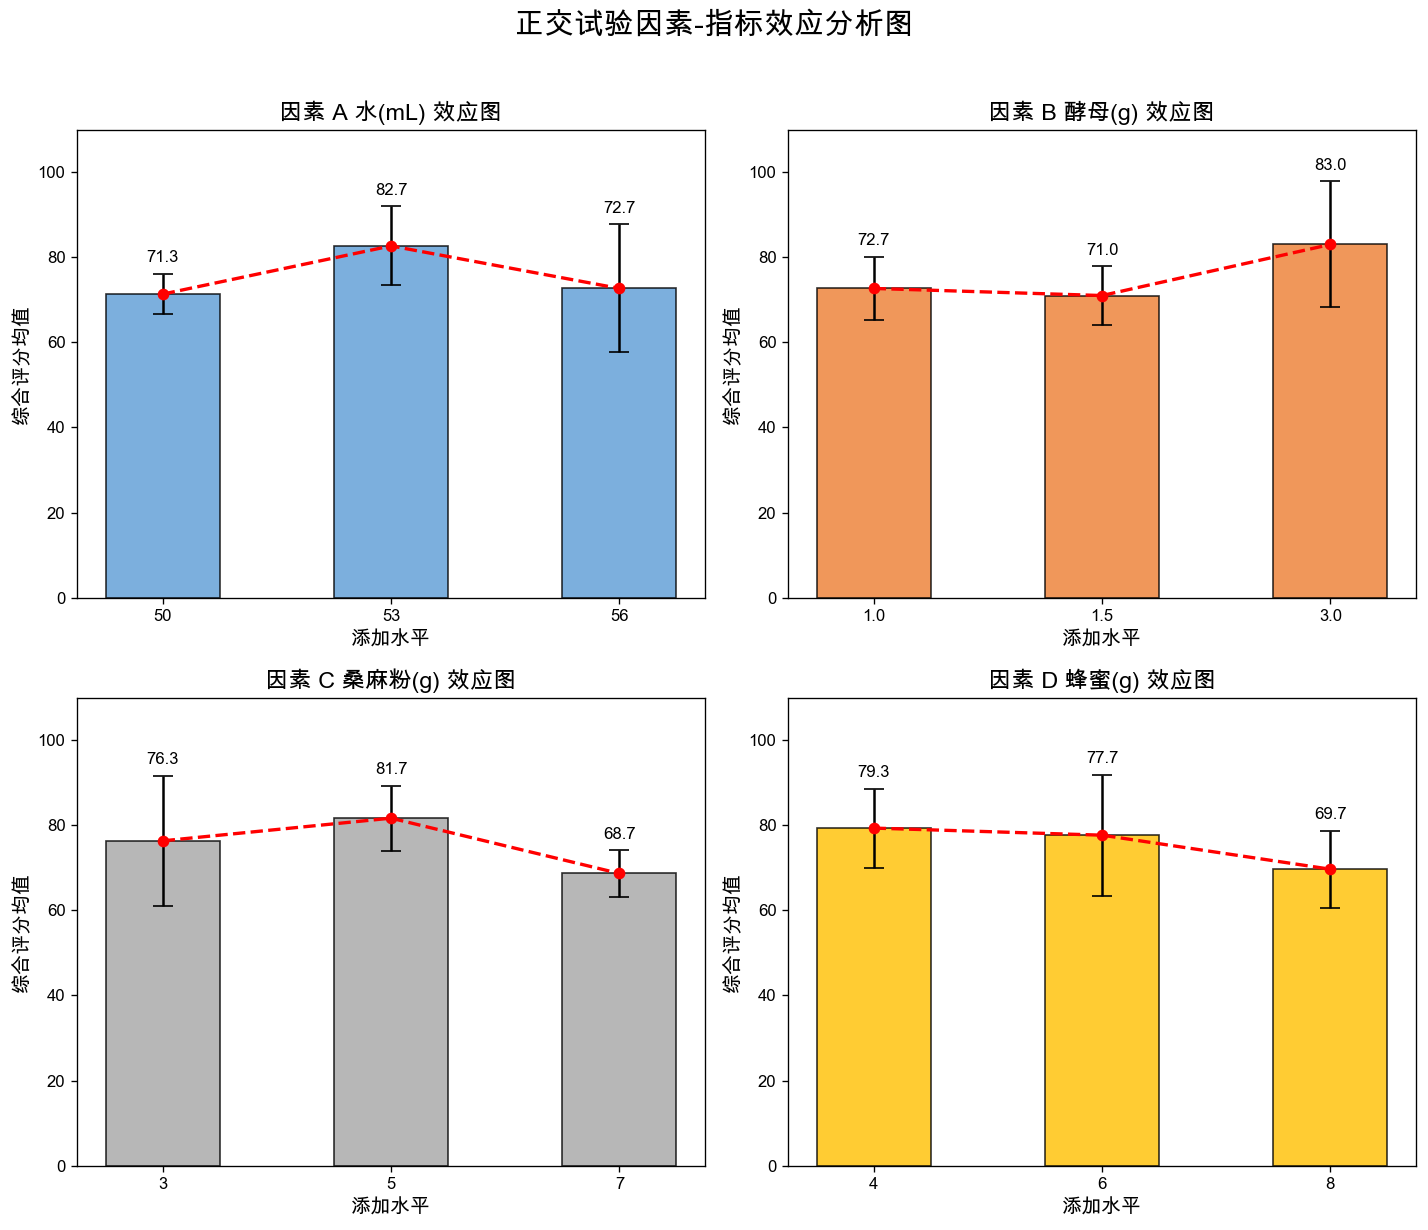

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.font_manager as fm

# ==========================================
# 1. 环境配置：字体与数据准备
# ==========================================
def set_chinese_font():
    font_names = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'STHeiti']
    for font in font_names:
        if font in [f.name for f in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [font]
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

set_chinese_font()

# 原始数据
data = {
    'A 水(mL)': [50, 50, 50, 53, 53, 53, 56, 56, 56],
    'B 酵母(g)': [1.0, 1.5, 3.0, 1.0, 1.5, 3.0, 1.0, 1.5, 3.0],
    'C 桑麻粉(g)': [3, 5, 7, 5, 7, 3, 7, 3, 5],
    'D 蜂蜜(g)': [4, 6, 8, 8, 4, 6, 6, 8, 4],
    '综合评分': [73, 75, 66, 80, 75, 93, 65, 63, 90]
}
df = pd.DataFrame(data)
factors = ['A 水(mL)', 'B 酵母(g)', 'C 桑麻粉(g)', 'D 蜂蜜(g)']

# ==========================================
# 2. 绘图逻辑
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=120)
axes = axes.flatten()

colors = ['#5B9BD5', '#ED7D31', '#A5A5A5', '#FFC000'] # 经典商务配色

for i, factor in enumerate(factors):
    ax = axes[i]
    
    # 分组计算均值 (k值) 和 标准差 (用于误差棒)
    stats = df.groupby(factor)['综合评分'].agg(['mean', 'std']).reset_index()
    
    # 转换为字符串标签，防止坐标轴变成连续数值
    x_labels = [str(x) for x in stats[factor]]
    means = stats['mean']
    stds = stats['std'].fillna(0) # 如果某组只有一个数据，标准差设为0
    
    # 绘制柱状图
    bars = ax.bar(x_labels, means, yerr=stds, color=colors[i], alpha=0.8, 
                  edgecolor='black', capsize=6, width=0.5, label='均值 (k)')
    
    # 叠加趋势折线 (效应图的灵魂)
    ax.plot(x_labels, means, marker='o', color='red', linestyle='--', linewidth=2, label='趋势')
    
    # 细节美化
    ax.set_title(f'因素 {factor} 效应图', fontsize=14, fontweight='bold')
    ax.set_ylabel('综合评分均值', fontsize=12)
    ax.set_xlabel('添加水平', fontsize=12)
    ax.set_ylim(0, 110) # 评分通常在100以内，留出顶部空间
    
    # 在柱子上方标注数值
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + stds[bars.index(bar)] + 2,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('正交试验因素-指标效应分析图', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# 保存图片
plt.savefig('正交试验效应图.png', dpi=300, bbox_inches='tight')
plt.show()


在完成数据计算与图表绘制后，我们需要将这些枯燥的数字转化为逻辑严密的文字描述。这部分内容通常出现在论文的“结果与分析”章节。

以下是为您撰写的正交试验分析说明，涵盖了从极差分析到最优组合确定的全过程 👇

## 🧭 试验分析概述
本研究采用 $$L_9(3^4)$$ 正交试验设计，选取水添加量（A）、酵母添加量（B）、桑麻粉添加量（C）及蜂蜜添加量（D）四个因素，每个因素设置三个水平，以综合评分为评价指标。通过极差分析（Range Analysis）来探讨各因素对产品品质的影响主次顺序，并确定最佳工艺参数组合。

---

## 🔍 极差分析与因素影响评价

### 1. 因素主次顺序的判定
极差值 $$R$$ 反映了各因素水平变化时对综合评分的影响程度。$$R$$ 值越大，说明该因素对指标的影响越显著，即为主要因素。
根据计算结果，各因素的极差大小排序为：
**$$R_C (13.00) > R_B (12.00) > R_A (11.34) > R_D (9.66)$$**

由此可知，各因素对产品综合评分的影响主次顺序依次为：**桑麻粉添加量 (C) > 酵母添加量 (B) > 水添加量 (A) > 蜂蜜添加量 (D)**。其中，桑麻粉的添加量是影响产品品质最关键的因素。

### 2. 各因素水平的效应分析
通过观察各因素在不同水平下的均值 $$k$$，可以分析出单因素变化对品质的影响趋势：
- **因素 A (水)**：随着加水量的增加，评分呈现先上升后下降的趋势，在 $$A_2$$ (53mL) 时达到峰值 $$82.67$$ 分。
- **因素 B (酵母)**：评分在低水平和中水平时差异不大，但在高水平 $$B_3$$ (3.0g) 时显著提升，均值达到 $$83.00$$ 分。
- **因素 C (桑麻粉)**：表现出明显的中间高、两头低的特性，$$C_2$$ (5g) 水平下的均值 $$81.67$$ 分远高于其他水平。
- **因素 D (蜂蜜)**：随着蜂蜜添加量的增加，评分呈下降趋势，说明在该体系中，较低的蜂蜜浓度 $$D_1$$ (4g) 更受青睐。

---

## 💡 最优组合确定与总结

### 最佳工艺方案
根据极差分析中各因素的最优水平（即 $$k$$ 值最大处），确定的理论最优组合方案为：**$$A_2 B_3 C_2 D_1$$**。

| 因素 | 最优水平代号 | 对应物理数值 |
| :--- | :--- | :--- |
| **A 水** | $$A_2$$ | 53 mL |
| **B 酵母** | $$B_3$$ | 3.0 g |
| **C 桑麻粉** | $$C_2$$ | 5 g |
| **D 蜂蜜** | $$D_1$$ | 4 g |

### 结论综述
综合来看，桑麻粉作为核心原料，其配比对口感平衡至关重要；而酵母量的增加显著改善了产品的组织结构。虽然在 9 组原始试验中，试验编号 6 ($$A_2 B_3 C_1 D_2$$) 的得分最高（93分），但经过正交分析推导出的组合 $$A_2 B_3 C_2 D_1$$ 综合了各因素的最佳表现，理论上能获得更优且更稳定的产品质量。

在实际生产中，建议优先保证桑麻粉和酵母的精准配比，而蜂蜜量可根据成本或特定口味需求在 $$D_1$$ 附近做微调。